# FunSearch for CVRP: Sample-Efficient Heuristic Discovery

**Authors:** LAI Yikai, QIN Ziheng, QIN Yuancheng

Note: this notebook is just for idea demonstration purpose, for the full codebase, see: https://github.com/laiyk5/funsearch_cvrp

## Overview

This notebook demonstrates how to use LLM-driven evolutionary search (FunSearch) to automatically discover construction heuristics for the **Capacitated Vehicle Routing Problem (CVRP)**.

**What is CVRP?** Given a depot and a set of customers with demands, find the minimum-cost set of routes (starting and ending at the depot) such that:
- Every customer is visited exactly once
- The total demand on each route does not exceed vehicle capacity

**What is FunSearch?** FunSearch treats program synthesis as an evolutionary algorithm where an LLM acts as a mutation operator. We evolve a `priority()` function that guides a greedy route builder.

**Key Features of this Implementation:**
- Island-based evolution with behavioral clustering
- Train/test/validation splits to measure generalization
- Aggregate scoring (25th percentile) with generalization penalty
- Baselines: Nearest Neighbor, Clarke-Wright Savings, CW+2-opt

**Notebook Structure:**
1. Setup — install the package and dependencies
2. Data Loading — fetch CVRPLib instances
3. Baseline Evaluation — run classical heuristics
4. FunSearch Evolution — run LLM-driven search
5. Results Analysis — compare and visualize

## 1. Setup

Install the `funsearch-cvrp` package and its dependencies. In Colab, we install directly from the Git repository. If running locally with the repo checked out, use `pip install -e ".[dev]"` instead.

In [1]:
# Install the funsearch-cvrp package from GitHub (uncomment the line below)
# If you are running this notebook inside the cloned repo, use:  !pip install -e "."
!pip install -q git+https://github.com/laiyk5/funsearch_cvrp.git

# Additional packages for visualization and analysis in this notebook
!pip install -q matplotlib numpy scipy pandas

zsh:1: command not found: pip
zsh:1: command not found: pip


In [2]:
# Verify installation
import funsearch_cvrp
print("funsearch-cvrp version:", funsearch_cvrp.__version__ if hasattr(funsearch_cvrp, "__version__") else "installed")

# Standard imports used throughout the notebook
import os
import json
import math
import time
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Callable, Any

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

funsearch-cvrp version: installed


## 2. Data Loading

We use the **CVRPLib A-set** (27 instances, 32–80 customers) as our benchmark. Each instance comes with a known optimal or best-known solution.

If the data is not present locally, we download it from the [CVRPLib repository](http://vrp.galgos.inf.puc-rio.br/index.php/en/).

In [3]:
from funsearch_cvrp.cvrp.io import load_cvrplib_folder
from funsearch_cvrp.cvrp.core import CVRPInstance, Solution

# Path to CVRPLib A-set instances
DATA_DIR = Path("../data/cvrplib/A")

# If running in Colab without local data, download a small subset
if not DATA_DIR.exists():
    import urllib.request
    import zipfile

    DATA_DIR = Path("/content/cvrplib_a")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    base_url = "http://vrp.galgos.inf.puc-rio.br/media/com_vrp/instances/A/"

    # Download a few representative instances
    names = ["A-n32-k5", "A-n37-k5", "A-n44-k6", "A-n54-k7", "A-n60-k9", "A-n69-k9", "A-n80-k10"]
    for name in names:
        for ext in [".vrp", ".sol"]:
            url = f"{base_url}{name}{ext}"
            dst = DATA_DIR / f"{name}{ext}"
            if not dst.exists():
                try:
                    urllib.request.urlretrieve(url, dst)
                except Exception as e:
                    print(f"Failed to download {name}{ext}: {e}")

# Load all instances with their optimal solutions
instances_data = load_cvrplib_folder(DATA_DIR)
print(f"Loaded {len(instances_data)} instances")

# Print a summary of the first few instances
for inst, sol, opt in instances_data[:3]:
    print(f"  {inst.name}: {inst.n_customers} customers, capacity={inst.capacity}, optimal={opt}")

Loaded 27 instances
  A-n32-k5: 31 customers, capacity=100, optimal=784.0
  A-n33-k5: 32 customers, capacity=100, optimal=661.0
  A-n33-k6: 32 customers, capacity=100, optimal=742.0


In [4]:
# Split into train / validation / test sets
# We hold out 15% for validation and 20% for test to measure generalization
random.seed(42)
indices = list(range(len(instances_data)))
random.shuffle(indices)

n_val = max(1, int(len(indices) * 0.15))
n_test = max(1, int(len(indices) * 0.20))

val_indices = indices[:n_val]
test_indices = indices[n_val:n_val + n_test]
train_indices = indices[n_val + n_test:]

train_data = [instances_data[i] for i in train_indices]
val_data = [instances_data[i] for i in val_indices]
test_data = [instances_data[i] for i in test_indices]

print(f"Train: {len(train_data)} instances")
print(f"Validation: {len(val_data)} instances")
print(f"Test: {len(test_data)} instances")

Train: 18 instances
Validation: 4 instances
Test: 5 instances


## 3. Baseline Evaluation

Before running FunSearch, we establish baseline performance using classical hand-designed heuristics:

1. **Nearest Neighbor (NN)** — greedily visit the closest feasible customer
2. **Clarke-Wright Savings (CW)** — merge routes based on distance savings
3. **CW + 2-opt** — apply 2-opt local search to CW routes

We report the **gap** above optimal: `(distance - optimal) / optimal`.

In [5]:
from funsearch_cvrp.cvrp.core import (
    solution_distance, is_valid_solution, gap_score, make_greedy_solver
)
from funsearch_cvrp.cvrp.baselines import (
    nearest_neighbor_heuristic,
    clarke_wright_savings_heuristic,
    with_two_opt,
)

def evaluate_on_split(data: list[tuple[CVRPInstance, Solution, float]], solver_fn: Callable) -> dict:
    """Evaluate a solver on a data split. Returns gaps and distances per instance."""
    results = []
    for inst, _, opt in data:
        routes = solver_fn(inst)
        valid, reason = is_valid_solution(inst, routes)
        dist = solution_distance(inst, routes)
        gap = gap_score(dist, opt) if opt > 0 else 0
        results.append({
            "instance": inst.name,
            "valid": valid,
            "distance": dist,
            "optimal": opt,
            "gap": gap,
            "n_routes": len(routes),
        })
    return results

def summarize(results: list[dict]) -> dict:
    """Compute mean gap and other summary statistics."""
    gaps = [r["gap"] for r in results if r["valid"]]
    return {
        "mean_gap": np.mean(gaps) if gaps else float("inf"),
        "median_gap": np.median(gaps) if gaps else float("inf"),
        "max_gap": np.max(gaps) if gaps else float("inf"),
        "valid_count": sum(1 for r in results if r["valid"]),
    }

In [6]:
# Run all baselines on the training set
baselines = {
    "Nearest Neighbor": nearest_neighbor_heuristic,
    "Clarke-Wright Savings": clarke_wright_savings_heuristic,
    "CW + 2-opt": with_two_opt(clarke_wright_savings_heuristic),
}

baseline_results = {}
for name, solver in baselines.items():
    results = evaluate_on_split(train_data, solver)
    baseline_results[name] = results
    summary = summarize(results)
    print(f"{name:30s}  mean_gap={summary['mean_gap']:.2%}  valid={summary['valid_count']}/{len(results)}")

Nearest Neighbor                mean_gap=40.58%  valid=18/18
Clarke-Wright Savings           mean_gap=5.06%  valid=18/18
CW + 2-opt                      mean_gap=4.78%  valid=18/18


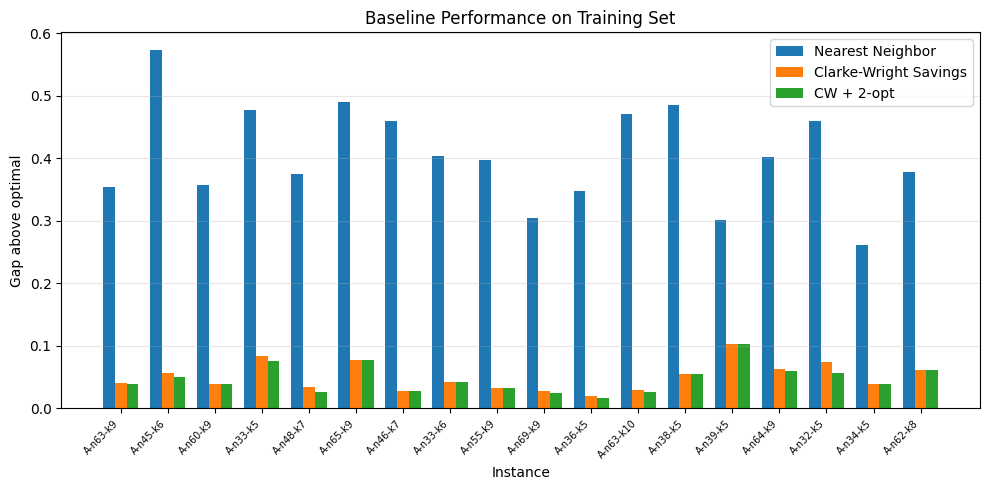

In [7]:
# Visualize baseline gaps per instance
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(train_data))
width = 0.25
instance_names = [inst.name for inst, _, _ in train_data]

for i, (name, results) in enumerate(baseline_results.items()):
    gaps = [r["gap"] for r in results]
    ax.bar(x + i * width, gaps, width, label=name)

ax.set_xlabel("Instance")
ax.set_ylabel("Gap above optimal")
ax.set_title("Baseline Performance on Training Set")
ax.set_xticks(x + width)
ax.set_xticklabels(instance_names, rotation=45, ha="right", fontsize=7)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. FunSearch Evolution

FunSearch evolves a `priority()` function that guides a greedy route builder. The LLM proposes improvements to the function, and an island-based evolutionary algorithm maintains diversity.

### 4.1 Define the Evaluation Harness

The evaluator runs the greedy solver with the evolved priority function on all training instances and returns the negative gap (so higher = better, matching FunSearch's maximization convention).

In [8]:
from funsearch_cvrp.funsearch.code_manipulation import text_to_program
from funsearch_cvrp.funsearch.config import ProgramsDatabaseConfig
from funsearch_cvrp.funsearch.programs_database import (
    ProgramsDatabase, ScoreReductionConfig, _reduce_score
)
from funsearch_cvrp.funsearch.evaluator import Evaluator, SimpleSandbox
from funsearch_cvrp.funsearch.sampler import LLM, Sampler

# The specification file content — this is the template FunSearch mutates
SPEC_CODE = '''
def priority(
  current_node: int,
  candidate: int,
  instance,
  remaining_capacity: int,
  route: list,
  route_demand: int,
  unserved: set,
) -> float:
  """Score a candidate customer for the greedy route builder."""
  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur
'''

template = text_to_program(SPEC_CODE)
function_to_evolve = "priority"

# Prepare training inputs: (instance, optimal_distance) pairs
train_inputs = [(inst, opt) for inst, _, opt in train_data]

def evaluate_cvrp(test_input, priority_fn):
    """
    Evaluate a priority function on a single CVRP instance.
    Returns negative gap (higher is better). Invalid solutions get -1e9.
    """
    instance, optimal = test_input
    solver = make_greedy_solver(priority_fn)
    routes = solver(instance)
    valid, reason = is_valid_solution(instance, routes)
    if not valid:
        return -1e9
    dist = solution_distance(instance, routes)
    gap = gap_score(dist, optimal)
    return -gap  # FunSearch maximizes, so negate the gap

### 4.2 Configure the Programs Database

We use 10 islands with aggregate scoring (25th percentile) and a small generalization penalty to discourage overfitting.

In [9]:
# Configure the evolutionary database
db_config = ProgramsDatabaseConfig(
    num_islands=10,
    reset_period=600,          # Reset weakest islands every 10 minutes
    functions_per_prompt=3,     # Number of prior versions in each LLM prompt
    cluster_sampling_temperature_init=0.1,
    cluster_sampling_temperature_period=1000,
    score_bucket_precision=None,  # Exact signature matching
    score_reduction_method="percentile_25",  # Use 25th percentile instead of last instance
    generalization_penalty=0.05,  # Penalize high variance across instances
)

database = ProgramsDatabase(
    config=db_config,
    template=template,
    function_to_evolve=function_to_evolve,
)

# Create evaluator
evaluator = Evaluator(
    database=database,
    template=template,
    function_to_evolve=function_to_evolve,
    evaluate_fn=evaluate_cvrp,
    inputs=train_inputs,
    timeout_seconds=30,
    sandbox=SimpleSandbox(),
)

# Seed the database with the template function so islands are not empty.
# We evaluate the initial priority() on all training instances and register
# it in every island (island_id=None triggers all-island registration).
initial_body = template.get_function(function_to_evolve).body
evaluator.analyse(initial_body, island_id=None, version_generated=None)

print("Database and evaluator initialized.")
print(f"  Islands: {db_config.num_islands}")
print(f"  Score reduction: {db_config.score_reduction_method}")
print(f"  Generalization penalty: {db_config.generalization_penalty}")
print(f"  Training instances: {len(train_inputs)}")

  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur
  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur
  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur
  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur
  import math
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur
  import math
  d_cu

Database and evaluator initialized.
  Islands: 10
  Score reduction: percentile_25
  Generalization penalty: 0.05
  Training instances: 18


### 4.3 Mock LLM for Demonstration

To make the notebook runnable without an API key, we provide a `MockLLM` that generates simple variations of the priority function. For real evolution, swap this for `OpenAILLM` with your API credentials.

In [10]:
class MockLLM(LLM):
    """A mock LLM that generates simple priority function variations for demonstration."""

    def __init__(self, samples_per_prompt: int = 2):
        super().__init__(samples_per_prompt)
        self._variations = [
            # v0: original nearest neighbor
            """  import math\n
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  return -d_cur""",
            # v1: weight by demand ratio
            """  import math\n
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  demand_ratio = instance.demands[candidate] / instance.capacity
  return -d_cur + 0.5 * demand_ratio""",
            # v2: penalize distance to depot
            """  import math\n
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  d_dep = math.hypot(
    instance.coords[candidate][0] - instance.coords[0][0],
    instance.coords[candidate][1] - instance.coords[0][1],
  )
  return -d_cur - 0.3 * d_dep""",
            # v3: combine demand and depot distance
            """  import math\n
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  d_dep = math.hypot(
    instance.coords[candidate][0] - instance.coords[0][0],
    instance.coords[candidate][1] - instance.coords[0][1],
  )
  demand_ratio = instance.demands[candidate] / instance.capacity
  return -d_cur - 0.2 * d_dep + 0.4 * demand_ratio""",
            # v4: savings-like priority
            """  import math\n
  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  d_dep = math.hypot(
    instance.coords[candidate][0] - instance.coords[0][0],
    instance.coords[candidate][1] - instance.coords[0][1],
  )
  d_cur_dep = math.hypot(
    instance.coords[current_node][0] - instance.coords[0][0],
    instance.coords[current_node][1] - instance.coords[0][1],
  )
  saving = d_cur_dep + d_dep - d_cur
  return saving""",
        ]
        self._idx = 0

    def _draw_sample(self, prompt: str) -> str:
        code = self._variations[self._idx % len(self._variations)]
        self._idx += 1
        return code

# To use a real LLM, uncomment and configure below:
# from funsearch_cvrp.funsearch.sampler import OpenAILLM
# llm = OpenAILLM(
#     samples_per_prompt=2,
#     model="gpt-4",
#     temperature=0.7,
#     max_tokens=1000,
#     api_key=os.environ.get("OPENAI_API_KEY"),
# )

llm = MockLLM(samples_per_prompt=2)
sampler = Sampler(database=database, evaluators=[evaluator], llm=llm)

### 4.4 Run the Evolution Loop

We run a limited number of iterations for demonstration. In a real experiment, run 1000+ iterations. The loop samples prompts, generates code via LLM, evaluates on training instances, and registers accepted programs into the island database.

In [18]:
# Run FunSearch for a small number of iterations
N_ITERATIONS = 10  # Increase to 1000 for real experiments

history = []  # Track best score over iterations

for iteration in range(N_ITERATIONS):
    prompt = database.get_prompt()
    samples = llm.draw_samples(prompt.code)

    for sample in samples:
        scores = evaluator.analyse(
            sample=sample,
            island_id=prompt.island_id,
            version_generated=prompt.version_generated,
            iteration=iteration,
        )

    # Record current best score across all islands
    current_best = max(database._best_score_per_island)
    history.append(current_best)
    print(f"Iter {iteration:3d}: best_score={current_best:.4f}")

print("\nEvolution complete!")

Iter   0: best_score=-0.3521


Iter   1: best_score=-0.3521


Iter   2: best_score=-0.3521


Iter   3: best_score=-0.3521


KeyboardInterrupt: 

## 5. Results Analysis

### 5.1 Evolution Trajectory

Plot how the best score improved over iterations.

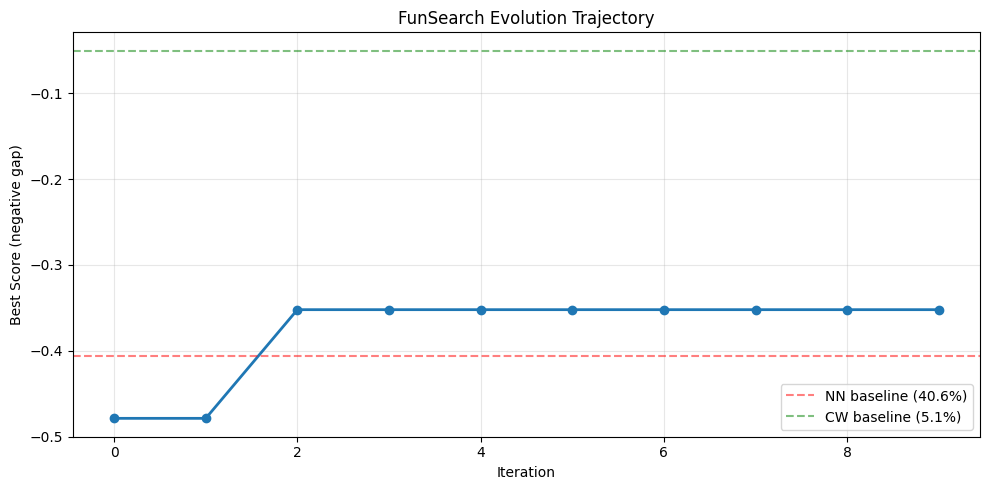

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history, marker="o", linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Best Score (negative gap)")
ax.set_title("FunSearch Evolution Trajectory")
ax.grid(alpha=0.3)
# Add horizontal lines for baseline reference
nn_gap = np.mean([r["gap"] for r in baseline_results["Nearest Neighbor"]])
cw_gap = np.mean([r["gap"] for r in baseline_results["Clarke-Wright Savings"]])
ax.axhline(-nn_gap, color="red", linestyle="--", alpha=0.5, label=f"NN baseline ({nn_gap:.1%})")
ax.axhline(-cw_gap, color="green", linestyle="--", alpha=0.5, label=f"CW baseline ({cw_gap:.1%})")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Extract the Best Evolved Function

Retrieve the best priority function found during evolution and inspect its code.

In [13]:
# Find the island with the best score
best_island = int(np.argmax(database._best_score_per_island))
best_program = database._best_program_per_island[best_island]
best_score = database._best_score_per_island[best_island]

print(f"Best island: {best_island}")
print(f"Best score: {best_score:.4f}")
print("\nBest evolved priority function:\n")
print(best_program.body if best_program else "No program found")

Best island: 0
Best score: -0.3521

Best evolved priority function:

  import math

  d_cur = math.hypot(
    instance.coords[current_node][0] - instance.coords[candidate][0],
    instance.coords[current_node][1] - instance.coords[candidate][1],
  )
  d_dep = math.hypot(
    instance.coords[candidate][0] - instance.coords[0][0],
    instance.coords[candidate][1] - instance.coords[0][1],
  )
  d_cur_dep = math.hypot(
    instance.coords[current_node][0] - instance.coords[0][0],
    instance.coords[current_node][1] - instance.coords[0][1],
  )
  saving = d_cur_dep + d_dep - d_cur
  return saving


### 5.3 Evaluate Best Function on Validation and Test Sets

Measure generalization by evaluating the best evolved function on held-out validation and test instances. This is critical because LLM-generated heuristics can overfit to training instance structure.

In [14]:
# Reconstruct the full function from the template + evolved body
from funsearch_cvrp.funsearch.code_manipulation import text_to_function
import copy

def make_solver_from_program(program, template, function_to_evolve):
    """Create an executable solver from an evolved program."""
    prog = copy.deepcopy(template)
    evolved_fn = prog.get_function(function_to_evolve)
    evolved_fn.body = program.body
    # Compile the function
    namespace = {}
    exec(str(prog), namespace)
    priority_fn = namespace[function_to_evolve]
    return make_greedy_solver(priority_fn)

if best_program:
    evolved_solver = make_solver_from_program(best_program, template, function_to_evolve)

    train_results = evaluate_on_split(train_data, evolved_solver)
    val_results = evaluate_on_split(val_data, evolved_solver)
    test_results = evaluate_on_split(test_data, evolved_solver)

    train_summary = summarize(train_results)
    val_summary = summarize(val_results)
    test_summary = summarize(test_results)

    print("Generalization Report:")
    print(f"  Train  mean_gap = {train_summary['mean_gap']:.2%}")
    print(f"  Val    mean_gap = {val_summary['mean_gap']:.2%}")
    print(f"  Test   mean_gap = {test_summary['mean_gap']:.2%}")
    print(f"\nTrain-Test gap difference: {test_summary['mean_gap'] - train_summary['mean_gap']:.2%}")

Generalization Report:
  Train  mean_gap = 29.18%
  Val    mean_gap = 26.03%
  Test   mean_gap = 28.89%

Train-Test gap difference: -0.29%


### 5.4 Comparison Table

Summarize all methods in a single table.

,Method,Mean Gap,Valid
0,Nearest Neighbor,40.58%,18/18
1,Clarke-Wright Savings,5.06%,18/18
2,CW + 2-opt,4.78%,18/18
3,FunSearch (best),29.18%,18/18
4,FunSearch (test),28.89%,5/5


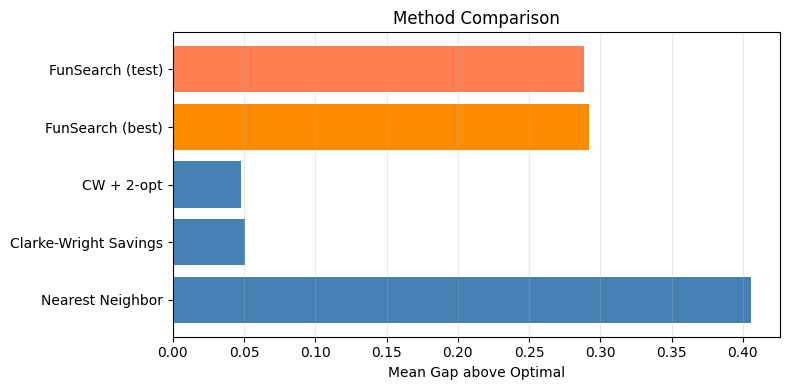

In [15]:
import pandas as pd

rows = []
for name, results in baseline_results.items():
    s = summarize(results)
    rows.append({"Method": name, "Mean Gap": f"{s['mean_gap']:.2%}", "Valid": f"{s['valid_count']}/{len(results)}"})

if best_program:
    rows.append({
        "Method": "FunSearch (best)",
        "Mean Gap": f"{train_summary['mean_gap']:.2%}",
        "Valid": f"{train_summary['valid_count']}/{len(train_results)}",
    })
    rows.append({
        "Method": "FunSearch (test)",
        "Mean Gap": f"{test_summary['mean_gap']:.2%}",
        "Valid": f"{test_summary['valid_count']}/{len(test_results)}",
    })

df = pd.DataFrame(rows)
display(df)

# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 4))
methods = df["Method"].tolist()
gaps = [float(row["Mean Gap"].replace("%", "")) / 100 for _, row in df.iterrows()]
colors = ["steelblue"] * len(baseline_results) + ["darkorange", "coral"]
ax.barh(methods, gaps, color=colors)
ax.set_xlabel("Mean Gap above Optimal")
ax.set_title("Method Comparison")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Load and Analyze Existing Experiment

Instead of running evolution inside the notebook, you can load an existing experiment output (e.g., from a long-running `scripts/run/run_funsearch.py` process) and visualize its results. This is useful for monitoring progress or comparing completed runs.

Set `EXPERIMENT_DIR` to the path of your run directory (e.g., `outputs/latest/run_funsearch`).

In [35]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Path to an existing experiment output directory
EXPERIMENT_DIR = Path("../outputs/latest/run_funsearch")

def load_jsonl(path: Path):
    """Load a JSONL file, skipping empty lines."""
    if not path.exists():
        return []
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

eval_records = load_jsonl(EXPERIMENT_DIR / "eval" / "eval.jsonl")
db_records = load_jsonl(EXPERIMENT_DIR / "database" / "database.jsonl")

print(f"Loaded {len(eval_records)} eval records")
print(f"Loaded {len(db_records)} database records")
print(f"Experiment: {EXPERIMENT_DIR}")

Loaded 161 eval records
Loaded 160 database records
Experiment: ../outputs/latest/run_funsearch


### 6.1 Summary Statistics

In [36]:
if eval_records:
    accepted = sum(1 for r in eval_records if r.get("accepted"))
    rejected = sum(1 for r in eval_records if not r.get("accepted"))
    milestones = sum(1 for r in eval_records if r.get("is_milestone"))
    last = eval_records[-1]
    print("=== Experiment Summary ===")
    print(f"  Total evaluations: {len(eval_records)}")
    print(f"  Accepted: {accepted}")
    print(f"  Rejected: {rejected}")
    print(f"  Milestones: {milestones}")
    print(f"  Last iteration: {last.get('iteration', 'N/A')}")
    print(f"  Last island: {last.get('island_id', 'N/A')}")

    # Best program if available
    best_path = EXPERIMENT_DIR / "best_program.py"
    if best_path.exists():
        print(f"\n  Best program: {best_path}")
        with open(best_path) as f:
            best_code = f.read()
        print(f"  Best program length: {len(best_code)} chars")
    else:
        print("\n  No best_program.py found yet.")
else:
    print("No eval records found.")

=== Experiment Summary ===
  Total evaluations: 161
  Accepted: 153
  Rejected: 8
  Milestones: 21
  Last iteration: 159
  Last island: 8

  Best program: ../outputs/latest/run_funsearch/best_program.py
  Best program length: 2264 chars


### 6.2 Overall Evolution Trajectory

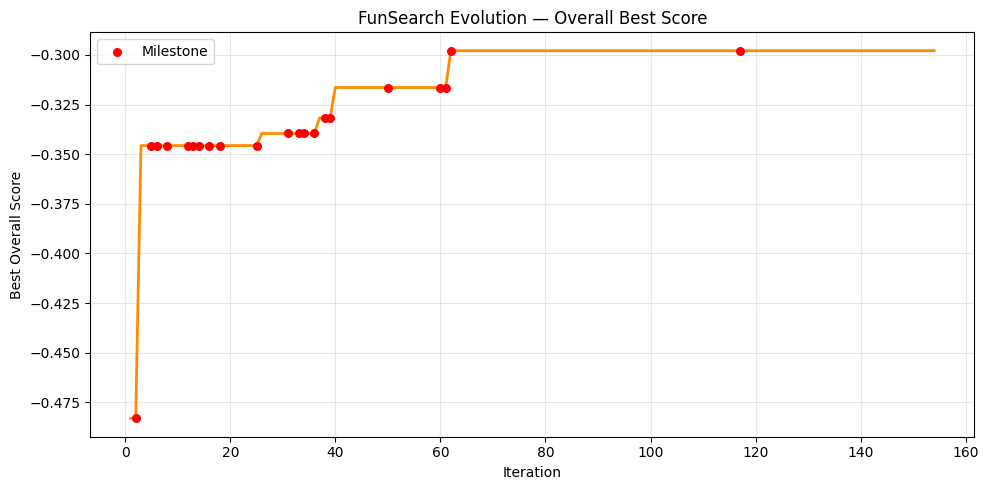

In [29]:
if db_records:
    iterations = [r["iteration"] for r in db_records]
    best_scores = [r["overall_best"] for r in db_records]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(iterations, best_scores, linewidth=2, color="darkorange")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best Overall Score")
    ax.set_title("FunSearch Evolution — Overall Best Score")
    ax.grid(alpha=0.3)

    # Mark milestones from eval records
    milestone_iters = [r["iteration"] for r in eval_records if r.get("is_milestone")]
    if milestone_iters:
        # Find corresponding best scores at milestone iterations
        db_map = {r["iteration"]: r["overall_best"] for r in db_records}
        milestone_scores = [db_map.get(it, None) for it in milestone_iters]
        milestone_iters = [it for it, sc in zip(milestone_iters, milestone_scores) if sc is not None]
        milestone_scores = [sc for sc in milestone_scores if sc is not None]
        ax.scatter(milestone_iters, milestone_scores, color="red", zorder=5, s=30, label="Milestone")
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No database records found.")

### 6.3 Per-Island Trajectories

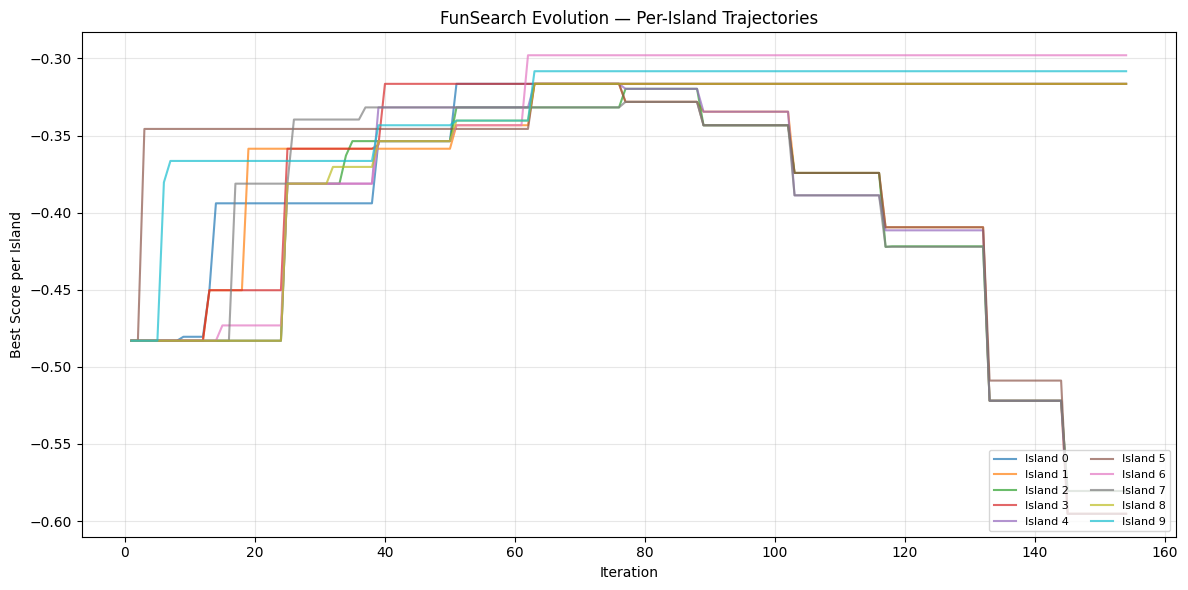

In [30]:
if db_records:
    fig, ax = plt.subplots(figsize=(12, 6))

    # Determine number of islands from first record
    n_islands = len(db_records[0].get("best_score_per_island", []))
    iterations = [r["iteration"] for r in db_records]

    for i in range(n_islands):
        scores = [r["best_score_per_island"][i] for r in db_records if i < len(r["best_score_per_island"])]
        # Only plot if island has non-trivial values
        if any(s > -1 for s in scores):
            ax.plot(iterations[:len(scores)], scores, alpha=0.7, label=f"Island {i}")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best Score per Island")
    ax.set_title("FunSearch Evolution — Per-Island Trajectories")
    ax.legend(loc="lower right", ncol=2, fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No database records found.")

### 6.4 Acceptance Rate Over Time

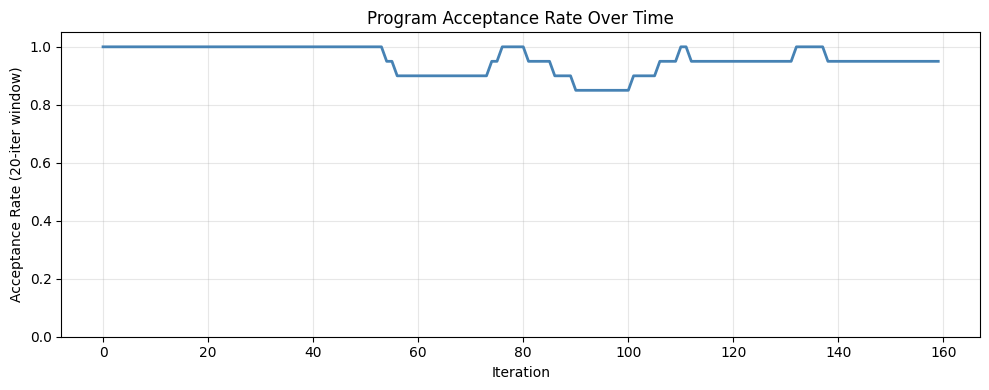

In [37]:
if eval_records:
    window = 20
    # Filter to records that have the expected keys
    clean = [r for r in eval_records if "iteration" in r and "accepted" in r]
    if not clean:
        print("No valid eval records with 'iteration' key found.")
    else:
        iters = [r["iteration"] for r in clean]
        accepted = [1 if r.get("accepted") else 0 for r in clean]

        # Rolling acceptance rate
        rolling = []
        for i in range(len(accepted)):
            start = max(0, i - window + 1)
            rolling.append(np.mean(accepted[start:i+1]))

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(iters, rolling, color="steelblue", linewidth=2)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(f"Acceptance Rate ({window}-iter window)")
        ax.set_title("Program Acceptance Rate Over Time")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No eval records found.")


### 6.5 Best Program Code

In [ ]:
best_path = EXPERIMENT_DIR / "best_program.py"
if best_path.exists():
    with open(best_path) as f:
        best_code = f.read()
    print("=== Best Evolved Program ===\n")
    print(best_code)
else:
    print("No best_program.py found yet. It is written whenever a new overall best is discovered.")

### 6.6 Score Distribution Across Recent Evaluations

In [ ]:
if eval_records:
    # Compute per-evaluation max score across test instances
    max_scores = []
    eval_iters = []
    eval_accepted = []
    for r in eval_records:
        if "iteration" not in r:
            continue
        spt = r.get("scores_per_test", {})
        if spt:
            max_scores.append(max(spt.values()))
        else:
            max_scores.append(np.nan)
        eval_iters.append(r["iteration"])
        eval_accepted.append(r.get("accepted", False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram of max scores
    valid_scores = [s for s in max_scores if not np.isnan(s) and s > -1e8]
    axes[0].hist(valid_scores, bins=30, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Max Score per Evaluation")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Score Distribution (Accepted)")
    axes[0].grid(axis="y", alpha=0.3)

    # Score over iteration
    colors = ["green" if a else "red" for a in eval_accepted]
    axes[1].scatter(eval_iters, max_scores, c=colors, alpha=0.5, s=15)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Max Score")
    axes[1].set_title("All Evaluations (Green=Accepted, Red=Rejected)")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No eval records found.")


## 7. Optional: Run with Real LLM

To run FunSearch with a real LLM (e.g., GPT-4, DeepSeek, or Qwen), set your API key and replace the `MockLLM` with `OpenAILLM`.

**Note:** Real evolution requires significant API budget and time (~10+ hours for 1000 iterations).

In [ ]:
# Uncomment to configure a real LLM
import os
os.environ["OPENAI_API_KEY"] = "sk-..."  # Replace with your key
os.environ["OPENAI_BASE_URL"] = "https://api.openai.com/v1"  # Or your proxy

os.environ["OPENAI_API_KEY"] = "sk-2004560dfcdd4dd1a91961b17992e21b"
os.environ["OPENAI_BASE_URL"] = "https://api.deepseek.com"
openai_model = "deepseek-v4-flash"

from funsearch_cvrp.funsearch.sampler import OpenAILLM
llm = OpenAILLM(
    samples_per_prompt=2,
    model=openai_model,
    temperature=0.7,
    max_tokens=8000,
    api_key=os.environ.get("OPENAI_API_KEY"),
    base_url=os.environ.get("OPENAI_BASE_URL"),
)

# Then re-run the evolution cell (4.4) with the new llm

## 8. Save and Export

Save the best evolved function and the database checkpoint for later use.

In [17]:
# Save best program to a Python file
if best_program:
    output_dir = Path("colab_outputs")
    output_dir.mkdir(exist_ok=True)

    best_path = output_dir / "best_priority.py"
    with open(best_path, "w") as f:
        f.write(str(best_program))
    print(f"Saved best program to {best_path}")

    # Save database checkpoint
    checkpoint_path = output_dir / "checkpoint.pkl"
    database.save(checkpoint_path, metadata={"iterations": N_ITERATIONS})
    print(f"Saved checkpoint to {checkpoint_path}")

    # Save history as JSON
    history_path = output_dir / "history.json"
    with open(history_path, "w") as f:
        json.dump(history, f)
    print(f"Saved history to {history_path}")

Saved best program to colab_outputs/best_priority.py
Saved checkpoint to colab_outputs/checkpoint.pkl
Saved history to colab_outputs/history.json


---

## Summary

This notebook demonstrated:
1. **Loading CVRP benchmark instances** from CVRPLib
2. **Evaluating classical baselines** (NN, CW, CW+2-opt)
3. **Running FunSearch evolution** to discover greedy priority functions
4. **Measuring generalization** on held-out validation and test sets

**Key Takeaway:** FunSearch can automatically discover heuristics that outperform simple greedy strategies, but the gap to sophisticated algorithms like Clarke-Wright Savings remains. Most importantly, train/test splits are essential — LLM-generated heuristics can easily overfit to training instance structure.

For the full codebase, see: https://github.com/laiyk5/funsearch_cvrp